In [1]:
from sklearn.tree import ExtraTreeClassifier
from scipy.stats import randint, uniform
import sys
from pathlib import Path

# Go up one level to project root
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

from src.utils.tune_hyperparameters import ModelTuner, PipelineTuner
filename = r"../../data/raw/ACME-HappinessSurvey2020.csv"

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import ExtraTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

e:\dev\workspace\Apziva\Project1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
random_state = 0

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START classifier__criterion=gini, classifier__max_depth=2, classifier__max_features=log2, classifier__min_samples_leaf=4, classifier__min_samples_split=7, classifier__splitter=random
[CV 1/5; 1/100] END classifier__criterion=gini, classifier__max_depth=2, classifier__max_features=log2, classifier__min_samples_leaf=4, classifier__min_samples_split=7, classifier__splitter=random;, score=(train=0.625, test=0.450) total time=   0.0s
[CV 2/5; 1/100] START classifier__criterion=gini, classifier__max_depth=2, classifier__max_features=log2, classifier__min_samples_leaf=4, classifier__min_samples_split=7, classifier__splitter=random
[CV 2/5; 1/100] END classifier__criterion=gini, classifier__max_depth=2, classifier__max_features=log2, classifier__min_samples_leaf=4, classifier__min_samples_split=7, classifier__splitter=random;, score=(train=0.613, test=0.700) total time=   0.0s
[CV 3/5; 1/100] START classifier__crite

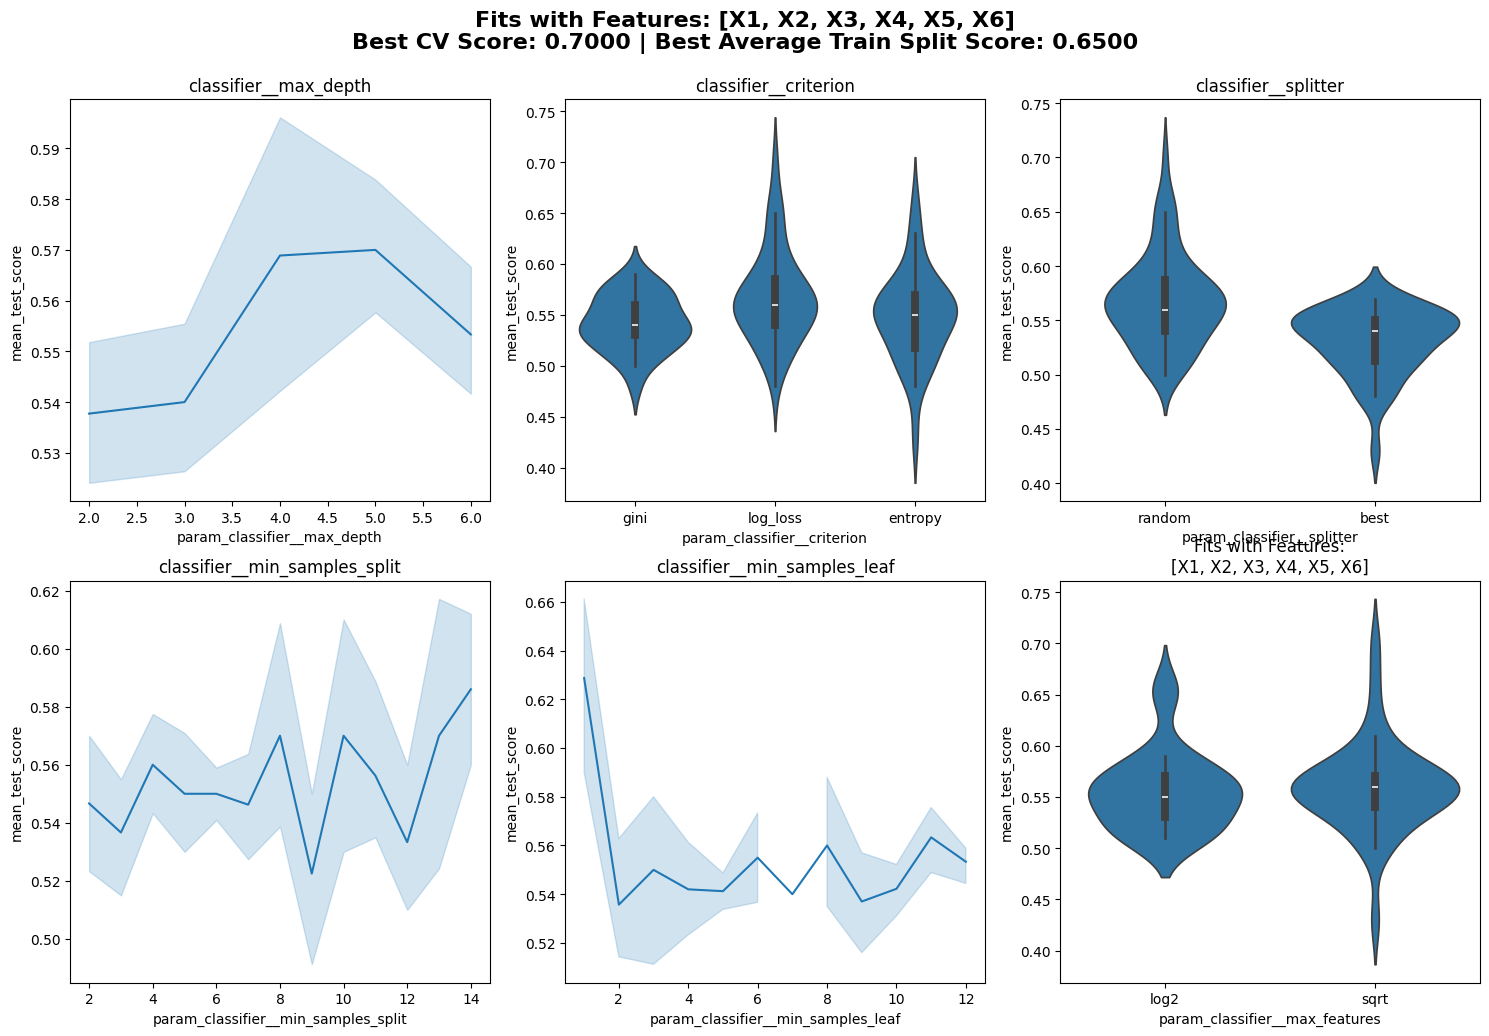



Feature Permutation Importance
______________________
X4: 0.012 +/- 0.025
X1: 0.004 +/- 0.047
X5: -0.008 +/- 0.062
X3: -0.012 +/- 0.060
X6: -0.038 +/- 0.034
X2: -0.092 +/- 0.046

______________________


e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:405: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values[:, :, i], X_test_transformed_df, show=False)


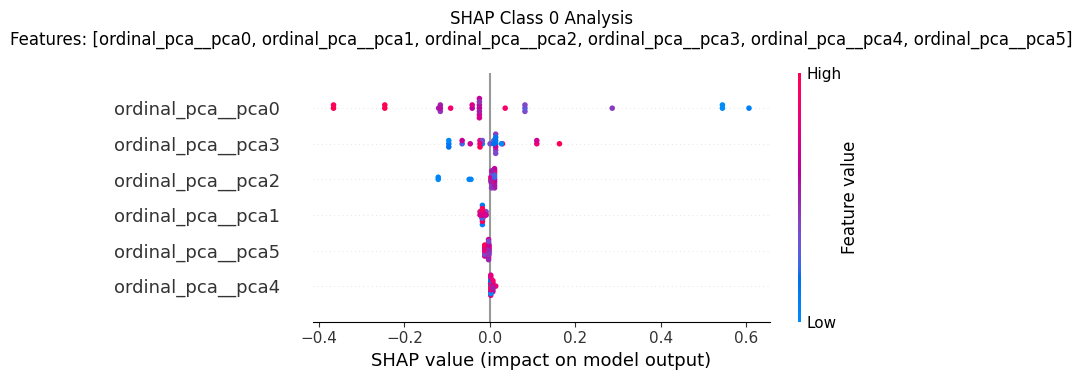

e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:405: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values[:, :, i], X_test_transformed_df, show=False)


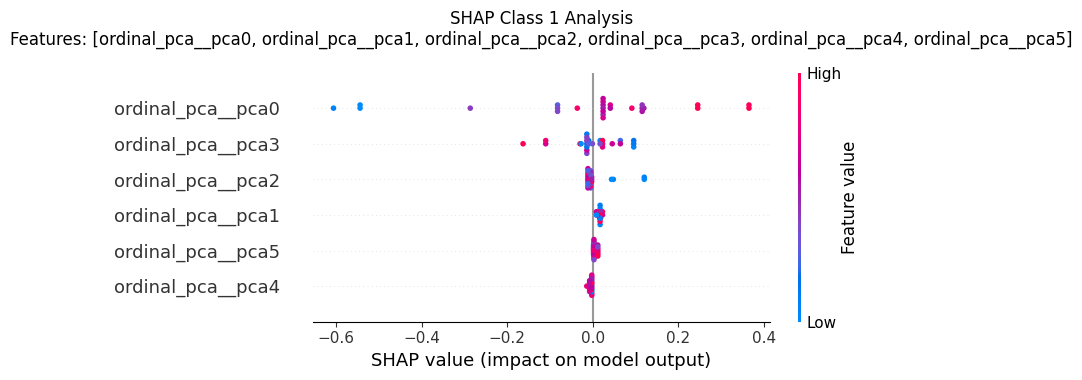

In [3]:
# 1. Define your 6 ordinal categorical features
categorical_features = ["X1", "X2", "X3", "X4", "X5", "X6"]

# 2. Create the PCA transformer step (Scale first, then reduce dimensionality)
pca_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler()),  # Centers and scales the 1-5 ordinal data
        ("pca", PCA(n_components=len(categorical_features))),  # Keeps all 6 principal components
    ]
)

# 3. Update the ColumnTransformer to apply PCA to your target features
preprocessor = ColumnTransformer(
    transformers=[
        (
            "ordinal_pca",
            pca_transformer,
            categorical_features,
        )  # Applies PCA to X1-X6
    ],
    remainder="passthrough",  # Keeps any other numerical columns untouched
)

# 4. Final Pipeline structure containing the PCA preprocessor and your classifier
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", ExtraTreeClassifier(random_state=random_state)),
    ]
)

t = PipelineTuner(pipeline, filename, "Y", categorical_features, random_state= random_state)

parameter_grid = {
                    'classifier__max_depth':randint(2,7),
                    'classifier__criterion':("gini", "entropy", "log_loss"),
                    'classifier__splitter': ("random", "best"),
                    'classifier__min_samples_split':randint(2,15),
                    'classifier__min_samples_leaf':randint(1,13),
                    'classifier__max_features': ("sqrt", "log2", None),
            }
search = t.tune_model(hyperParameterGrid=parameter_grid, n_iter = 100)
t.feature_permutation(search.best_params_)
t.shap_analysis(search.best_params_)

X2 and X6 actively hurt model performance. Retest with them removed

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START classifier__criterion=gini, classifier__max_depth=2, classifier__max_features=log2, classifier__min_samples_leaf=4, classifier__min_samples_split=7, classifier__splitter=random
[CV 1/5; 1/100] END classifier__criterion=gini, classifier__max_depth=2, classifier__max_features=log2, classifier__min_samples_leaf=4, classifier__min_samples_split=7, classifier__splitter=random;, score=(train=0.613, test=0.450) total time=   0.0s
[CV 2/5; 1/100] START classifier__criterion=gini, classifier__max_depth=2, classifier__max_features=log2, classifier__min_samples_leaf=4, classifier__min_samples_split=7, classifier__splitter=random
[CV 2/5; 1/100] END classifier__criterion=gini, classifier__max_depth=2, classifier__max_features=log2, classifier__min_samples_leaf=4, classifier__min_samples_split=7, classifier__splitter=random;, score=(train=0.575, test=0.700) total time=   0.0s
[CV 3/5; 1/100] START classifier__crite

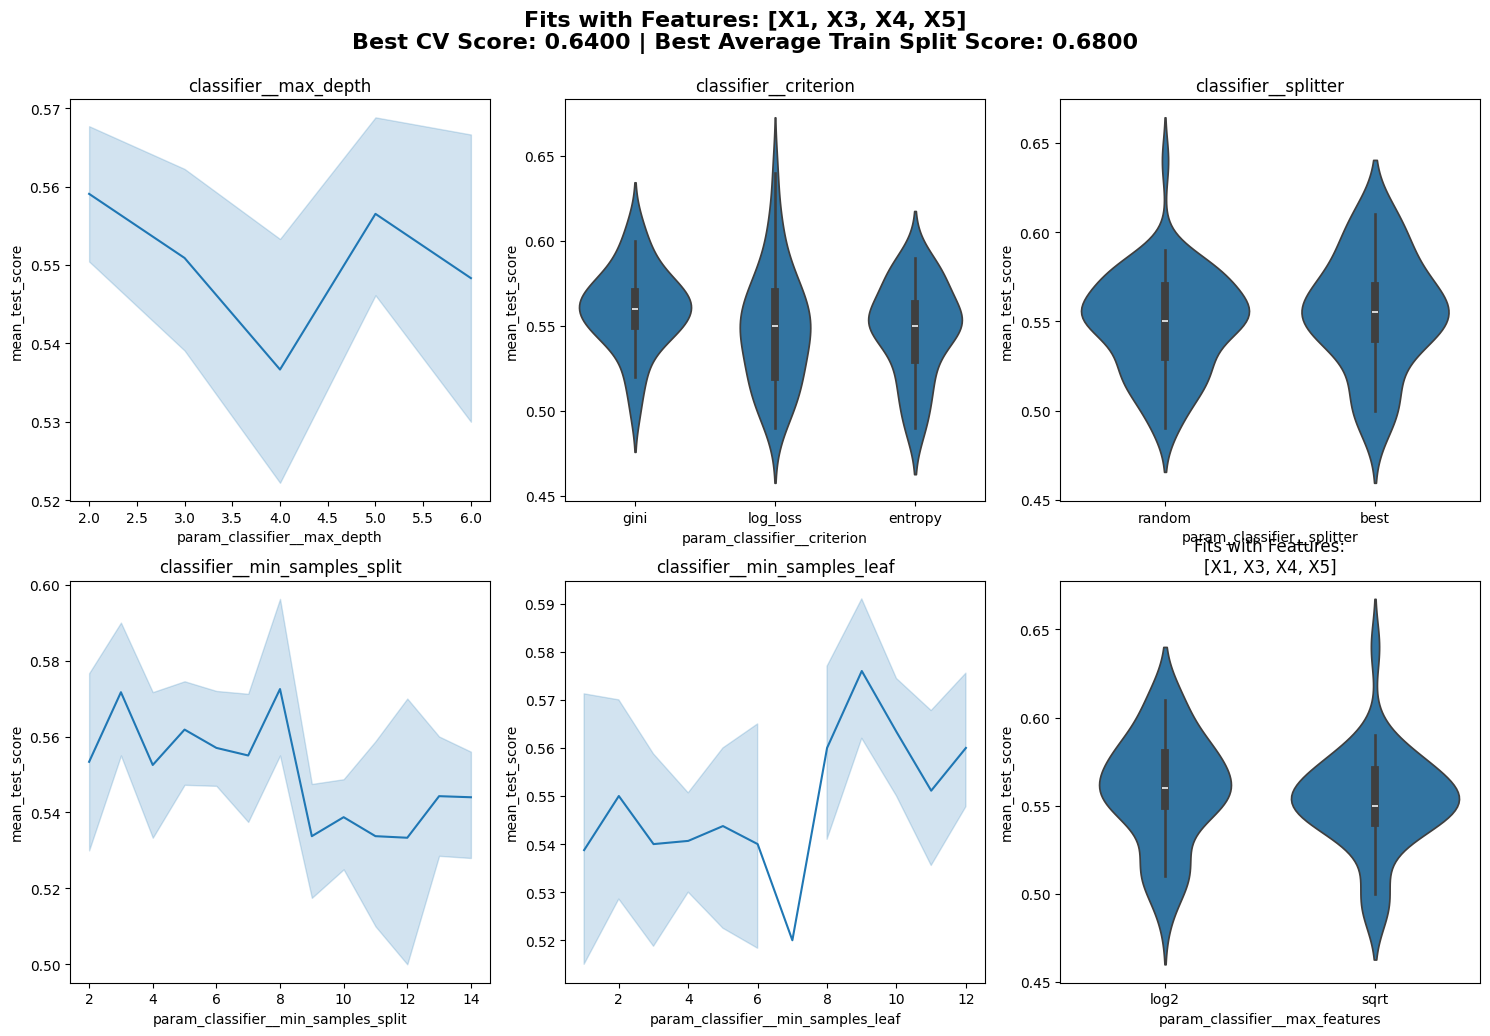



Feature Permutation Importance
______________________
X1: 0.004 +/- 0.047
X3: -0.031 +/- 0.029
X5: -0.046 +/- 0.077
X4: -0.112 +/- 0.072

______________________


e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:405: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values[:, :, i], X_test_transformed_df, show=False)


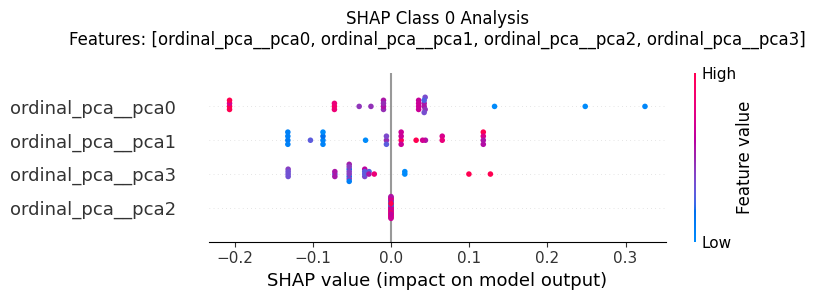

e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:405: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values[:, :, i], X_test_transformed_df, show=False)


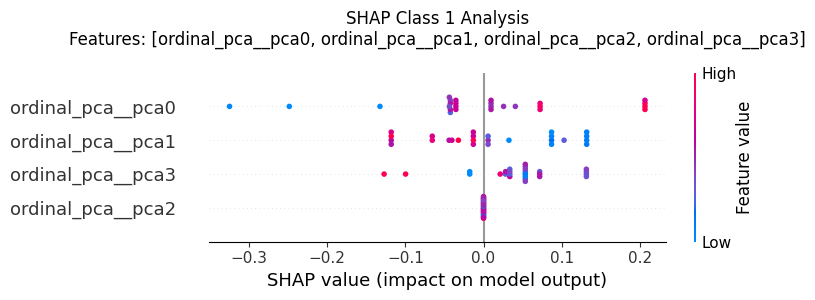

In [4]:
# 1. Define your 6 ordinal categorical features
categorical_features = ["X1", "X3", "X4", "X5"]

# 2. Create the PCA transformer step (Scale first, then reduce dimensionality)
pca_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler()),  # Centers and scales the 1-5 ordinal data
        ("pca", PCA(n_components=len(categorical_features))),  # Keeps all 6 principal components
    ]
)

# 3. Update the ColumnTransformer to apply PCA to your target features
preprocessor = ColumnTransformer(
    transformers=[
        (
            "ordinal_pca",
            pca_transformer,
            categorical_features,
        )  # Applies PCA to X1-X6
    ],
    remainder="passthrough",  # Keeps any other numerical columns untouched
)

# 4. Final Pipeline structure containing the PCA preprocessor and your classifier
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", ExtraTreeClassifier(random_state=random_state)),
    ]
)

t = PipelineTuner(pipeline, filename, "Y", categorical_features, random_state= random_state)

parameter_grid = {
                    'classifier__max_depth':randint(2,7),
                    'classifier__criterion':("gini", "entropy", "log_loss"),
                    'classifier__splitter': ("random", "best"),
                    'classifier__min_samples_split':randint(2,15),
                    'classifier__min_samples_leaf':randint(1,13),
                    'classifier__max_features': ("sqrt", "log2", None),
            }
search = t.tune_model(hyperParameterGrid=parameter_grid, n_iter = 100)
t.feature_permutation(search.best_params_)
t.shap_analysis(search.best_params_)

X4 is also bringing down performance

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START classifier__criterion=gini, classifier__max_depth=2, classifier__max_features=log2, classifier__min_samples_leaf=4, classifier__min_samples_split=7, classifier__splitter=random
[CV 1/5; 1/100] END classifier__criterion=gini, classifier__max_depth=2, classifier__max_features=log2, classifier__min_samples_leaf=4, classifier__min_samples_split=7, classifier__splitter=random;, score=(train=0.550, test=0.550) total time=   0.0s
[CV 2/5; 1/100] START classifier__criterion=gini, classifier__max_depth=2, classifier__max_features=log2, classifier__min_samples_leaf=4, classifier__min_samples_split=7, classifier__splitter=random
[CV 2/5; 1/100] END classifier__criterion=gini, classifier__max_depth=2, classifier__max_features=log2, classifier__min_samples_leaf=4, classifier__min_samples_split=7, classifier__splitter=random;, score=(train=0.550, test=0.550) total time=   0.0s
[CV 3/5; 1/100] START classifier__crite

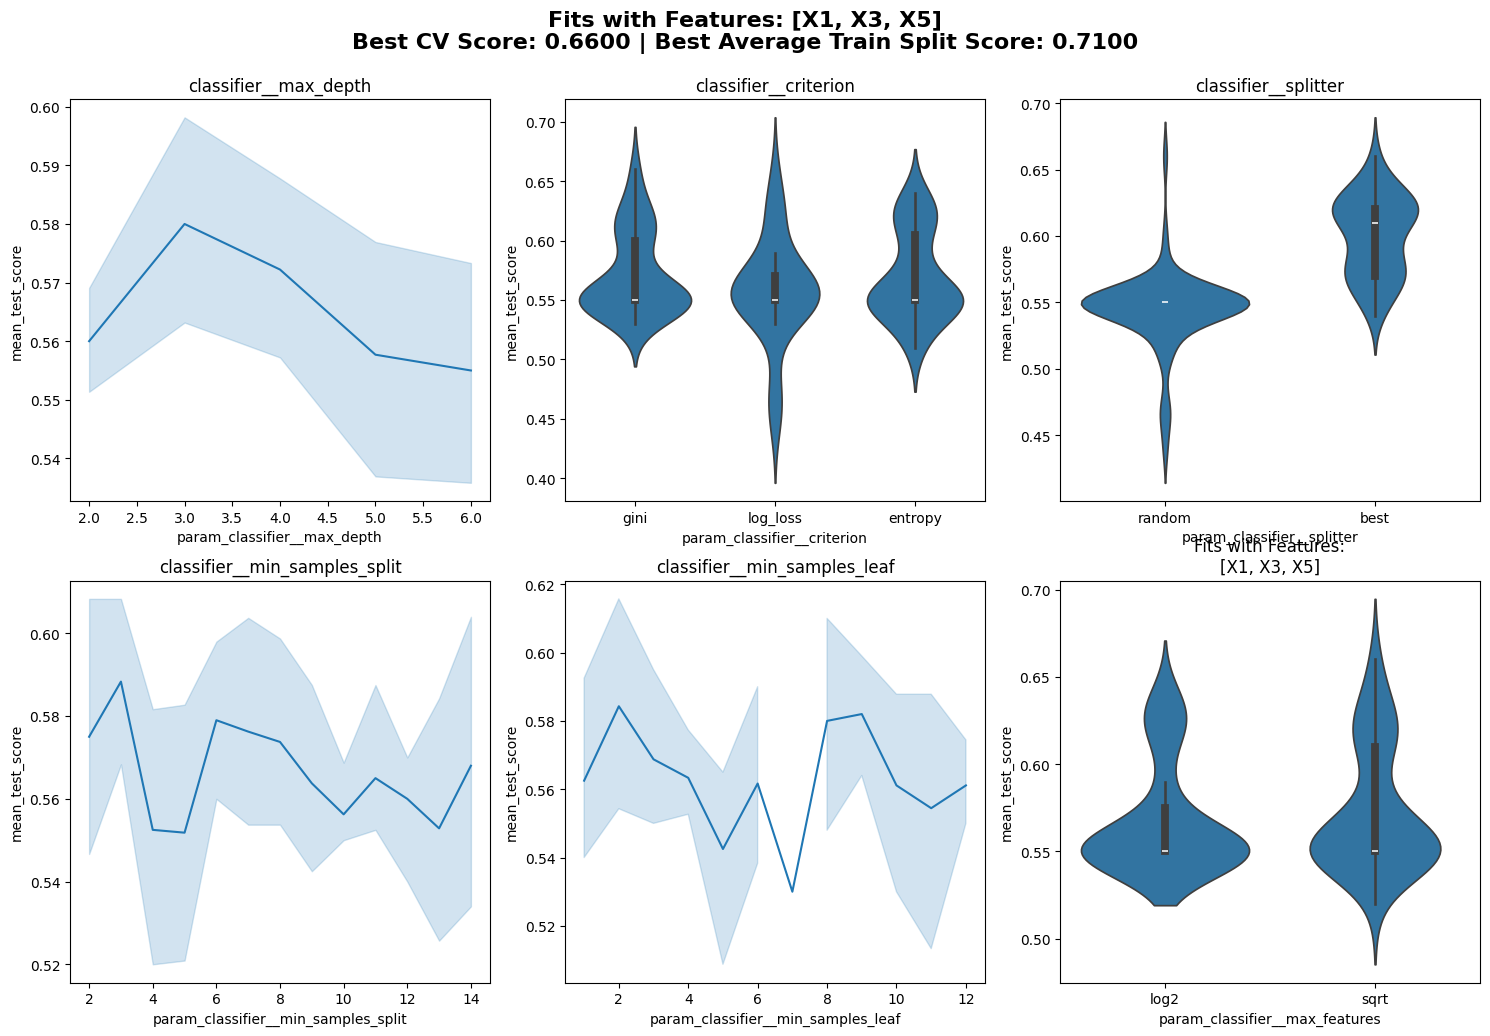



Feature Permutation Importance
______________________
X5: 0.158 +/- 0.070
X3: 0.088 +/- 0.052
X1: 0.035 +/- 0.058

______________________


e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:405: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values[:, :, i], X_test_transformed_df, show=False)


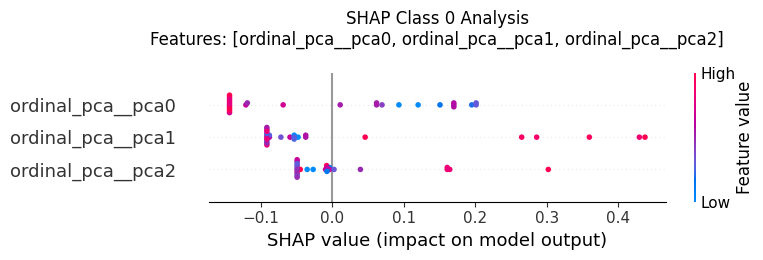

e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:405: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values[:, :, i], X_test_transformed_df, show=False)


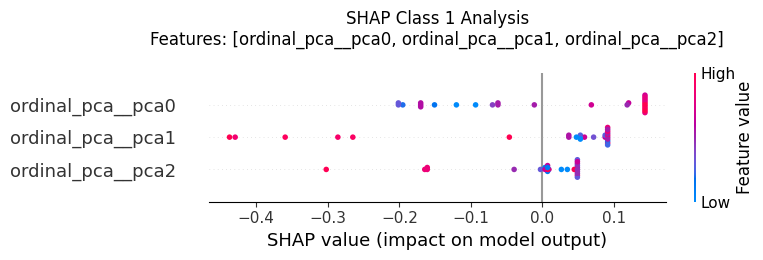

In [5]:
# 1. Define your 6 ordinal categorical features
categorical_features = ["X1","X3","X5"]

# 2. Create the PCA transformer step (Scale first, then reduce dimensionality)
pca_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler()),  # Centers and scales the 1-5 ordinal data
        ("pca", PCA(n_components=len(categorical_features))),  # Keeps all 6 principal components
    ]
)

# 3. Update the ColumnTransformer to apply PCA to your target features
preprocessor = ColumnTransformer(
    transformers=[
        (
            "ordinal_pca",
            pca_transformer,
            categorical_features,
        )  # Applies PCA to X1-X6
    ],
    remainder="passthrough",  # Keeps any other numerical columns untouched
)

# 4. Final Pipeline structure containing the PCA preprocessor and your classifier
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", ExtraTreeClassifier(random_state=random_state)),
    ]
)

t = PipelineTuner(pipeline, filename, "Y", categorical_features, random_state= random_state)

parameter_grid = {
                    'classifier__max_depth':randint(2,7),
                    'classifier__criterion':("gini", "entropy", "log_loss"),
                    'classifier__splitter': ("random", "best"),
                    'classifier__min_samples_split':randint(2,15),
                    'classifier__min_samples_leaf':randint(1,13),
                    'classifier__max_features': ("sqrt", "log2", None),
            }
search = t.tune_model(hyperParameterGrid=parameter_grid, n_iter = 100)
t.feature_permutation(search.best_params_)
t.shap_analysis(search.best_params_)

In [6]:
t.predict_test_split(t.last_search.best_params_)

0.6538461538461539

In [7]:
t.get_features()

['X1', 'X3', 'X5']

In [8]:
import pandas as pd
pd.DataFrame(t.last_search.cv_results_).loc[t.last_search.best_index_]


mean_fit_time                                                                   0.005057
std_fit_time                                                                    0.000486
mean_score_time                                                                 0.002819
std_score_time                                                                  0.000353
param_classifier__criterion                                                     log_loss
param_classifier__max_depth                                                            3
param_classifier__max_features                                                      sqrt
param_classifier__min_samples_leaf                                                     2
param_classifier__min_samples_split                                                    7
param_classifier__splitter                                                          best
params                                 {'classifier__criterion': 'log_loss', 'classif...
split0_test_score    

In [9]:
t.save_model(r"../../src/models/saved_models/ExtraTreeClassifierPCA", t.last_search.best_params_, True, notes= "CV score = 0.66; test score = 0.6538461538461539")

In [10]:
random_state += 1

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START classifier__criterion=entropy, classifier__max_depth=5, classifier__max_features=sqrt, classifier__min_samples_leaf=9, classifier__min_samples_split=11, classifier__splitter=best
[CV 1/5; 1/100] END classifier__criterion=entropy, classifier__max_depth=5, classifier__max_features=sqrt, classifier__min_samples_leaf=9, classifier__min_samples_split=11, classifier__splitter=best;, score=(train=0.725, test=0.650) total time=   0.0s
[CV 2/5; 1/100] START classifier__criterion=entropy, classifier__max_depth=5, classifier__max_features=sqrt, classifier__min_samples_leaf=9, classifier__min_samples_split=11, classifier__splitter=best
[CV 2/5; 1/100] END classifier__criterion=entropy, classifier__max_depth=5, classifier__max_features=sqrt, classifier__min_samples_leaf=9, classifier__min_samples_split=11, classifier__splitter=best;, score=(train=0.750, test=0.650) total time=   0.0s
[CV 3/5; 1/100] START classifie

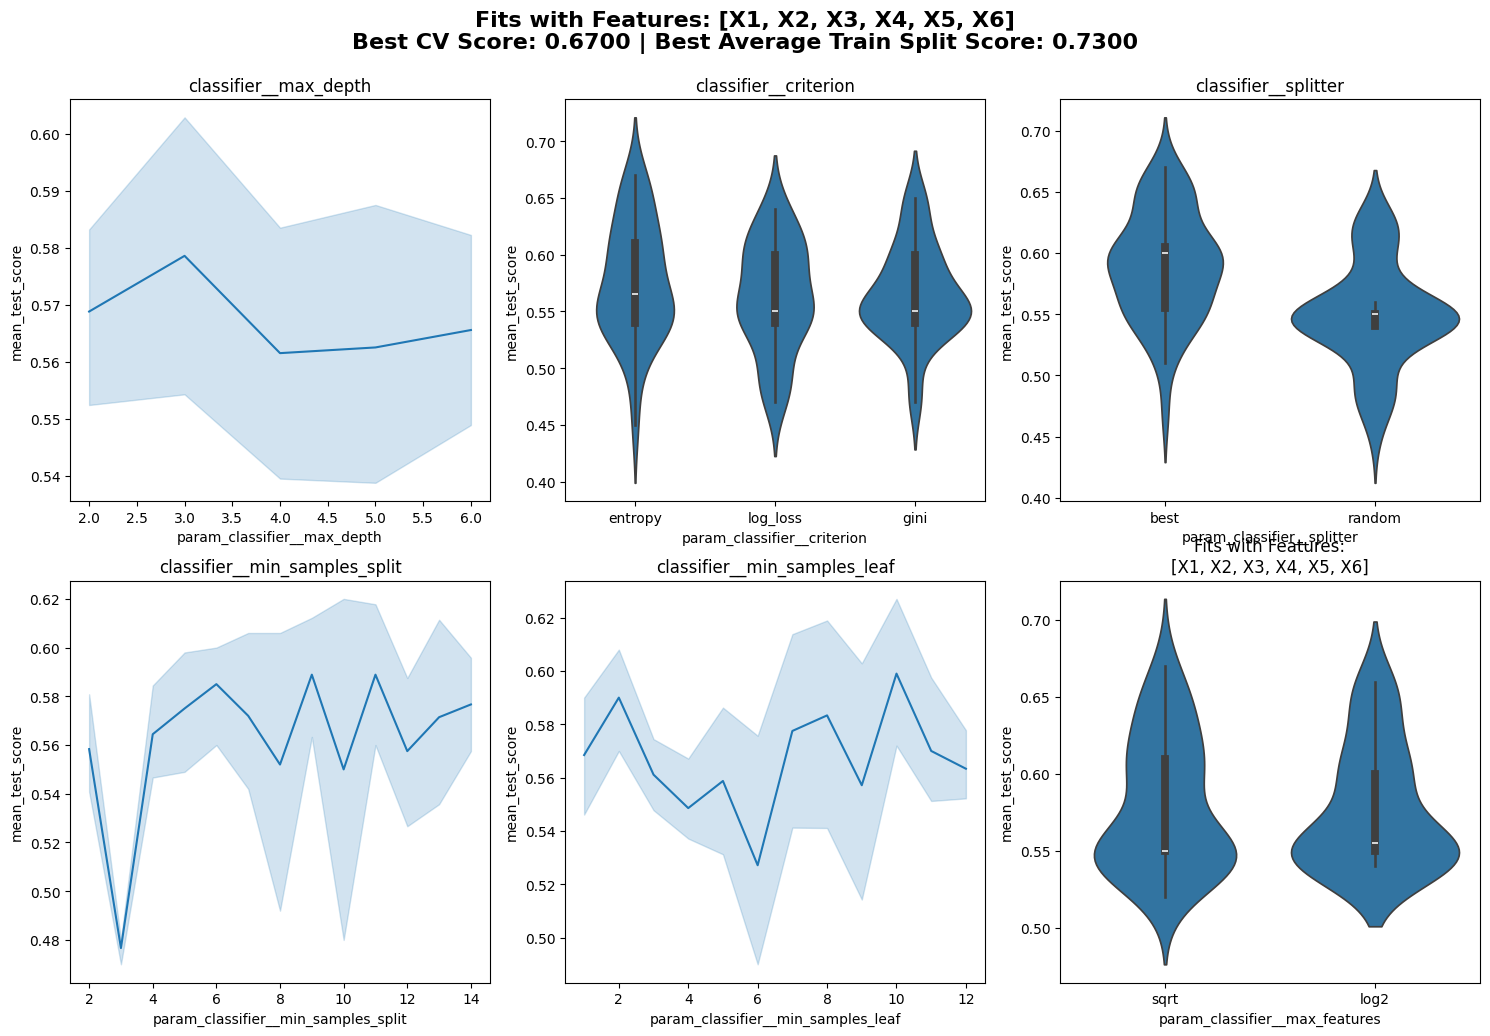



Feature Permutation Importance
______________________
X5: 0.035 +/- 0.068
X1: 0.015 +/- 0.058
X2: -0.015 +/- 0.031
X6: -0.023 +/- 0.067
X3: -0.027 +/- 0.064
X4: -0.038 +/- 0.054

______________________


e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:405: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values[:, :, i], X_test_transformed_df, show=False)


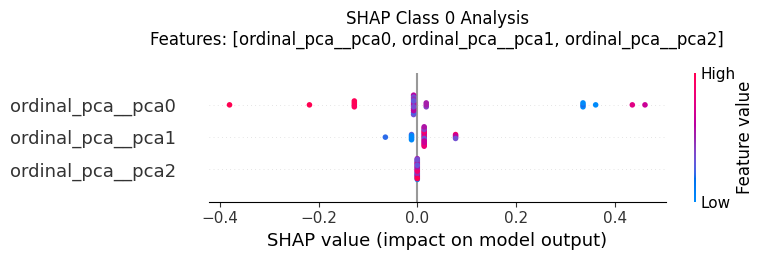

e:\dev\workspace\Apziva\Project1\src\utils\tune_hyperparameters.py:405: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values[:, :, i], X_test_transformed_df, show=False)


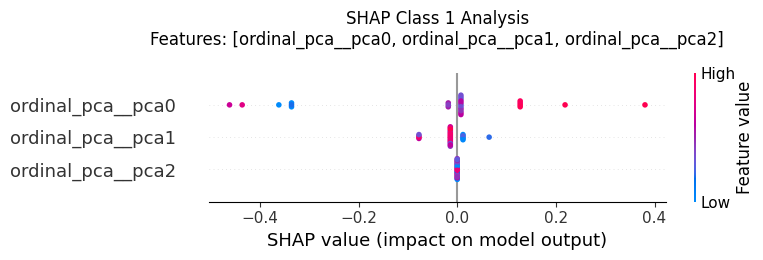

In [11]:
# 1. Define your 6 ordinal categorical features
categorical_features = ["X1", "X2", "X3", "X4", "X5", "X6"]

# 2. Create the PCA transformer step (Scale first, then reduce dimensionality)
pca_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler()),  # Centers and scales the 1-5 ordinal data
        ("pca", PCA(n_components=3)),  # Keeps all but one principal component
    ]
)

# 3. Update the ColumnTransformer to apply PCA to your target features
preprocessor = ColumnTransformer(
    transformers=[
        (
            "ordinal_pca",
            pca_transformer,
            categorical_features,
        )  # Applies PCA to X1-X6
    ],
    remainder="passthrough",  # Keeps any other numerical columns untouched
)

# 4. Final Pipeline structure containing the PCA preprocessor and your classifier
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", ExtraTreeClassifier(random_state=random_state)),
    ]
)

t1 = PipelineTuner(pipeline, filename, "Y", categorical_features, random_state= random_state)

parameter_grid = {
                    'classifier__max_depth':randint(2,7),
                    'classifier__criterion':("gini", "entropy", "log_loss"),
                    'classifier__splitter': ("random", "best"),
                    'classifier__min_samples_split':randint(2,15),
                    'classifier__min_samples_leaf':randint(1,13),
                    'classifier__max_features': ("sqrt", "log2", None),
            }
search = t1.tune_model(hyperParameterGrid=parameter_grid, n_iter = 100)
t1.feature_permutation(search.best_params_)
t1.shap_analysis(search.best_params_)

In [12]:
t1.predict_test_split(t1.last_search.best_params_)

0.5384615384615384